# TP : Algorithmes Genetiques pour la Detection de Bords avec PyGAD

**Navigation** : [Index](../../README.md) | [Search-5 GA >>](Part1-Foundations/Search-5-GeneticAlgorithms.ipynb)

Dans ce TP, nous implementerons un algorithme genetique (GA) en Python pour concevoir automatiquement un **filtre convolutif de detection de bords**. L'objectif est d'approximer un filtre connu (ici, le filtre **Sobel**) en utilisant la bibliotheque d'algorithmes genetiques [PyGAD](https://pygad.readthedocs.io).

### Objectifs du TP :

- Concevoir un chromosome representant un filtre convolutif.
- Definir une fonction d'evaluation mesurant la qualite d'un filtre par rapport au filtre de reference (Sobel).
- Configurer et executer l'algorithme genetique pour evoluer progressivement vers un filtre optimal.

> **Rappel :** Un **algorithme genetique** repose sur une analogie avec l'evolution biologique. Une population d'individus (solutions) est evaluee par une fonction dite de **fitness**. A chaque generation, on selectionne les meilleurs individus pour former de nouveaux individus par **croisement** et **mutation**, permettant ainsi une exploration efficace de l'espace de solutions.

## Technologies et Bibliothèques utilisées

- **PyGAD** :  
  Bibliothèque Python facilitant l'implémentation d'algorithmes génétiques avec une interface simple et intuitive. PyGAD permet une personnalisation complète des opérateurs génétiques (sélection, croisement, mutation).

- **OpenCV (cv2)** :  
  Bibliothèque largement utilisée en vision par ordinateur pour la manipulation et le traitement d'images. Elle est notamment utilisée ici pour les convolutions et le filtrage.

- **Matplotlib** :  
  Bibliothèque pour la visualisation des résultats intermédiaires et finaux directement dans le notebook Jupyter.

Ces outils sont combinés pour démontrer la puissance des algorithmes évolutionnaires dans l'optimisation automatique des filtres de traitement d'image.


In [1]:
%pip install pygad opencv-python-headless matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports et Fonctions Utilitaires

Nous allons commencer par importer les bibliothèques nécessaires et définir les fonctions utilitaires.

In [2]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pygad import pygad

# Mode batch pour exécution non-interactive (Papermill/MCP)
import os
BATCH_MODE = os.getenv("BATCH_MODE", "false").lower() in ("true", "1", "yes")
if BATCH_MODE:
    plt.ioff()  # Désactive le mode interactif matplotlib

# Fonction pour sauvegarder une image
def save_image(image, filename):
    cv2.imwrite(filename, image)
    print(f"Image enregistrée : {filename}")

# Fonction pour convertir une image Bitmap en Matrice OpenCV
def bitmap_to_mat(bitmap):
    return cv2.cvtColor(np.array(bitmap), cv2.COLOR_BGR2RGB)

# Fonction pour afficher une image
def display_image(image, title="Image"):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()  # Ferme la figure pour éviter blocage en mode batch

print(f"Imports OK : cv2, numpy, matplotlib, pygad | BATCH_MODE={BATCH_MODE}")

Imports OK : cv2, numpy, matplotlib, pygad | BATCH_MODE=False


## Définition du Chromosome (EdgeChromosome)

Dans cette implémentation, chaque chromosome représente un filtre de convolution complet. Il est composé d'un ensemble de **gènes**, chacun étant une matrice 7x7 de coefficients. Le filtre final appliqué à l'image correspond à la somme de toutes ces matrices de gènes.

### Pourquoi utiliser cette approche ?

- **Évolution progressive** : Chaque gène apporte une contribution partielle au filtre complet, permettant à l'algorithme d'explorer graduellement des solutions.
- **Exploration efficace** : La mutation et le croisement agissent sur des sous-unités indépendantes, augmentant la diversité et facilitant l'optimisation.

Ci-dessous, nous définissons la classe Python correspondant à cette représentation.


In [3]:
class EdgeChromosome:
    def __init__(self, length):
        self.kernel_size = 7  # Définir kernel_size avant de l'utiliser dans generate_gene
        self.length = length
        self.genes = [self.generate_gene() for _ in range(length)]

    def generate_gene(self):
        return np.random.randint(-20, 20, (self.kernel_size, self.kernel_size), dtype=np.int64)

    def get_complete_matrix(self):
        complete_matrix = np.zeros((self.kernel_size, self.kernel_size), dtype=np.float32)
        for gene in self.genes:
            complete_matrix += gene.astype(np.float32)
        
        max_abs = np.max(np.abs(complete_matrix))
        if max_abs > 10:
            complete_matrix = 10.0 * complete_matrix / max_abs
        return complete_matrix
print("Classe EdgeChromosome definie (representation genetique pour detection de contours)")


Classe EdgeChromosome definie (representation genetique pour detection de contours)


## Vérification du Chromosome créé

Testons maintenant la création d'un chromosome afin de vérifier que les gènes et la matrice résultante sont générés correctement.

**Attendu :** Une série de matrices 7x7 suivie d'une matrice résultante (somme normalisée).


In [4]:
test_chromosome = EdgeChromosome(5)
print("Gènes générés :")
for gene in test_chromosome.genes:
    print(gene)
    print()

test_matrix = test_chromosome.get_complete_matrix()
print("Matrice complète générée :")
print(test_matrix)

Gènes générés :
[[  6   2   4  18  -8 -15  -2]
 [ 12  -1  -4   0  -1 -14 -17]
 [ 19   4 -13  12 -14   0  -7]
 [  8 -15  -3  -3  -6 -15   9]
 [-18   7  -1  -1   1  -3  14]
 [-18   8  19   5   9   3 -19]
 [ -1   7  17 -18 -16 -20  12]]

[[ 17   4  -8  10   7  -4  19]
 [  3 -18   9 -12  -2   1 -10]
 [-11   3  -5  15   0  10  16]
 [ 18  15   3  -7   2 -17   9]
 [ 17  -2 -20 -18 -19  -2  12]
 [ -7   5   0  -1  -8   1  -8]
 [ -9  -5  -8  -7  15 -12  -3]]

[[-13 -13  -7  16 -17 -20  -8]
 [  4   5 -13  -6  -8   4 -17]
 [-12 -13   0   7 -17  10  10]
 [-17 -17  -5   9   8  -8   9]
 [ 13 -19  -4  12   4  14  15]
 [ 18 -13 -12   6 -10  -7  14]
 [ 19  -3   8 -11 -18 -11   4]]

[[ -3  13  17  16   6   8  17]
 [-12 -19  -5 -18  15 -12  -2]
 [-10  -2  -4  14 -12   7 -18]
 [  9   5 -17   2 -11  19  -2]
 [ -8 -14  -3  -5 -10   8  -9]
 [  8   7   7   0  10  13   2]
 [-20   1   2   9  -3   7  -6]]

[[-17   4 -10  -5 -10 -15   6]
 [ 13 -20   7  -8 -14  -8   5]
 [ -3 -17   9 -10  13 -16  16]
 [ -8   6   7  

## Fonction d'Évaluation (Fitness)

La **fonction d'évaluation** mesure la performance d'un filtre (chromosome) en comparant l'image obtenue par convolution avec l'image originale filtrée par le filtre Sobel (référence).  

### Étapes de l'évaluation :

1. **Filtrage convolutif** :  
   Le filtre généré par le chromosome est appliqué à l'image originale.

2. **Comparaison avec le filtre Sobel** :  
   L'image obtenue est comparée avec l'image de référence obtenue par le filtre Sobel, en utilisant une mesure de similarité (corrélation normalisée).

3. **Pénalisation des filtres uniformes** :  
   Pour éviter les solutions uniformes (avec des coefficients très faibles), une pénalité basée sur la somme absolue des coefficients du filtre est appliquée.

Cette approche permet de guider l'évolution vers des filtres capables de détecter efficacement les contours dans l'image.


In [5]:
import cv2
import numpy as np
import math

class EdgeFitness:
    def __init__(self, original_image):
        """
        Calcule l'image de référence via la magnitude du Sobel en X et Y, 
        normalisée dans la plage [0, 255].
        """
        # Conversion en niveaux de gris (8 bits)
        gray = cv2.cvtColor(np.array(original_image), cv2.COLOR_BGR2GRAY)

        # Sobel en X et Y
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

        # Magnitude = sqrt(SobelX^2 + SobelY^2)
        magnitude = np.sqrt(sobelx**2 + sobely**2)

        # Normalisation manuelle dans [0, 255]
        if magnitude.max() > 0:
            magnitude = (magnitude / magnitude.max()) * 255.0
        magnitude = magnitude.astype(np.uint8)

        self.reference_image = magnitude
        self.original_gray = gray  # on conserve l'image 8 bits en nuances de gris

    def display_images(self):
        """
        Affiche l'image d'origine (gris) et l'image Sobel de référence.
        """
        # Image originale
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.imshow(self.original_gray, cmap='gray')
        plt.title("Original Gray")
        plt.axis('off')

        # Image Sobel
        plt.subplot(1,2,2)
        plt.imshow(self.reference_image, cmap='gray')
        plt.title("Sobel Reference")
        plt.axis('off')
        plt.show()
        plt.close()  # Ferme la figure pour éviter blocage en mode batch

    def apply_filter(self, chromosome, display=False):
        """
        Construit la matrice complète du chromosome et l'applique sur l'image originale via cv2.filter2D.
        Retourne le résultat normalisé en [0,255].
        """
        # Reconstruction du noyau en float32
        filter_matrix = chromosome.get_complete_matrix()
        if display:
            print("Noyau généré :\n", filter_matrix)

        # Appliquer la convolution avec un borderType par défaut
        filtered_float = cv2.filter2D(self.original_gray.astype(np.float32), ddepth=-1, kernel=filter_matrix, borderType=cv2.BORDER_DEFAULT)

        # Conversion en uint8 sans normalisation excessive
        filtered_uint8 = cv2.convertScaleAbs(filtered_float)
        return filtered_uint8


    def evaluate(self, solution, solution_idx):
        """
        Transforme le 'solution' en chromosome, applique le filtre, 
        puis compare avec l'image Sobel de référence via la corrélation normalisée.
        Applique la pénalisation sur la somme des coefficients.
        """
        # Reconstruire le chromosome depuis le vecteur 'solution'
        from math import log10

        # On suppose 20 gènes de 7x7 = 49 coeff par gène
        gene_count = 20
        gene_size = 49
        chromosome = EdgeChromosome(gene_count)
        for i in range(gene_count):
            start = i*gene_size
            end   = start + gene_size
            arr   = np.array(solution[start:end]).reshape(7,7).astype(np.int64)
            chromosome.genes[i] = arr

        # Filtrage
        filtered_img = self.apply_filter(chromosome, display=False)

        # Vérifier la taille/dtype vs reference
        if filtered_img.shape != self.reference_image.shape:
            filtered_img = cv2.resize(filtered_img, 
                                      (self.reference_image.shape[1], 
                                       self.reference_image.shape[0]))

        # Corrélation normalisée
        result = cv2.matchTemplate(filtered_img, self.reference_image, cv2.TM_CCORR_NORMED)
        _, maxVal, _, _ = cv2.minMaxLoc(result)

        # Calcul de la pénalisation identique à GeneticSharp 
        # (log10(|sumCoeffs| + 1))
        full_matrix = chromosome.get_complete_matrix()
        filter_sum = np.sum(full_matrix)
        filter_penalty = 1.0
        if abs(filter_sum) >= 1e-3:
            filter_penalty = log10(abs(filter_sum) + 1.0)

        # Score final
        # multiplier éventuellement par 1000 pour avoir un range plus large
        score = (maxVal * 1000.0) / filter_penalty

        return score

    def display_chromosome_result(self, chromosome, filename_prefix, generation):
        """
        Affiche ou sauvegarde l'image filtrée (optionnel).
        """
        filtered_img = self.apply_filter(chromosome, display=True)
        filename = f"{filename_prefix}_generation_{generation}.png"

        cv2.imwrite(filename, filtered_img)
        print(f"Image enregistrée : {filename}")

        plt.figure()
        plt.imshow(filtered_img, cmap='gray')
        plt.title(f"Generation {generation}")
        plt.axis('off')
        plt.show()
        plt.close()  # Ferme la figure pour éviter blocage en mode batch
print("Classe EdgeFitness definie (evaluation fitness par comparaison Sobel)")


Classe EdgeFitness definie (evaluation fitness par comparaison Sobel)


### Test de la Fonction Fitness

Test de la fonction fitness.

In [6]:
from PIL import Image
# Test de la fonction fitness
# Resolution robuste du chemin image (CWD peut differer sous Papermill)
_here = Path().resolve()
for _candidate in [_here, _here / "MyIA.AI.Notebooks" / "Search"]:
    if (_candidate / "MRI_Prostate_Cancer.jpg").exists():
        _here = _candidate
        break
image_path = str(_here / "MRI_Prostate_Cancer.jpg")
original_image = Image.open(image_path)
fitness = EdgeFitness(original_image)

# Test d'un chromosome
chromosome = EdgeChromosome(20)
print(f"Score de fitness : {fitness.evaluate(np.concatenate([gene.flatten() for gene in chromosome.genes]), 0)}")


Score de fitness : 338.8559549305705


## Configuration de l'Algorithme Génétique avec PyGAD

Nous configurons l'algorithme génétique à l'aide des paramètres suivants :

- **Taille de la population :** Nombre total d'individus testés à chaque génération.
- **Sélection :** Stratégie pour choisir les parents les mieux adaptés (`"sss"` : steady-state selection).
- **Croisement :** Combinaison des gènes des parents pour créer des enfants (`"uniform"` : croisement uniforme).
- **Mutation :** Modifications aléatoires pour introduire de nouvelles variations (`"random"` avec 10 % de gènes mutés à chaque génération).
- **Critère d'arrêt :** Nombre fixé de générations (ici, 100 générations).

Ces choix influencent directement la qualité et la rapidité de la convergence vers une solution optimale.


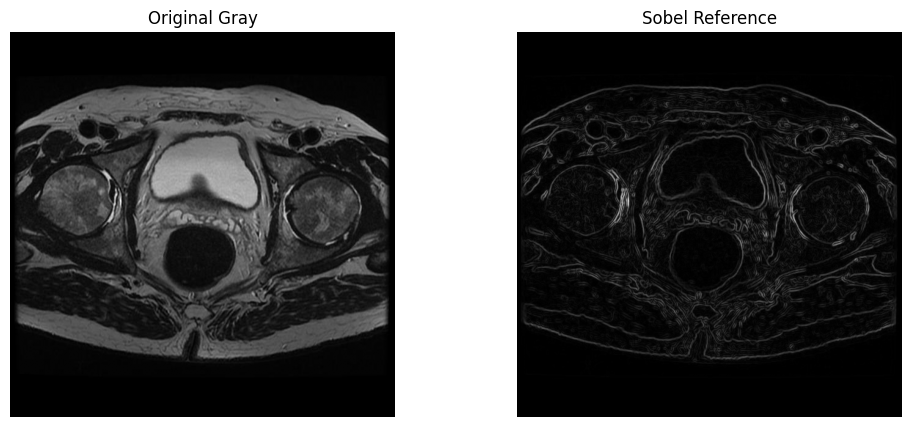

In [7]:
# -------------------------------------------------------------------
# A) Charger l'image avec PIL ou cv2, puis créer l'objet Fitness
# -------------------------------------------------------------------

# Resolution robuste du chemin image (CWD peut differer sous Papermill)
_here = Path().resolve()
for _candidate in [_here, _here / "MyIA.AI.Notebooks" / "Search"]:
    if (_candidate / "MRI_Prostate_Cancer.jpg").exists():
        _here = _candidate
        break
image_path = str(_here / "MRI_Prostate_Cancer.jpg")  # Remplacez par le chemin de votre image

original_image = Image.open(image_path)

# Créer notre objet fitness
fitness_object = EdgeFitness(original_image)
fitness_object.display_images()  # Pour vérifier l'image de référence Sobel

# -------------------------------------------------------------------
# B) Définir la fonction de fitness pour PyGAD
# -------------------------------------------------------------------
def fitness_func(ga_instance, solution, solution_idx):
    return fitness_object.evaluate(solution, solution_idx)

# -------------------------------------------------------------------
# C) Callback pour la visualisation à chaque génération
# -------------------------------------------------------------------
def on_generation(ga_instance):
    best_solution, best_solution_fitness, best_match_idx = ga_instance.best_solution()
    print(f"Génération {ga_instance.generations_completed} - Meilleur score : {best_solution_fitness}")

    # Affiche l'image tous les 10 tours
    if ga_instance.generations_completed % 10 == 0:
        # Reconstruire le chromosome
        gene_count = 20
        gene_size  = 49
        best_chromosome = EdgeChromosome(gene_count)
        for i in range(gene_count):
            start = i*gene_size
            end   = start + gene_size
            arr   = np.array(best_solution[start:end]).reshape(7,7).astype(np.int64)
            best_chromosome.genes[i] = arr

        fitness_object.display_chromosome_result(best_chromosome, "best", ga_instance.generations_completed)

# -------------------------------------------------------------------
# D) Configurer et lancer le GA
#    - 20 gènes, chaque gène = 7x7 = 49 coefficients
#    - On veut donc un chromosome de 20*49 = 980 coefficients
# -------------------------------------------------------------------
import pygad

chromosome_length = 20 * 49  # 980
population_size  = (100, chromosome_length)  # Ex.: 100 individus

ga_instance = pygad.GA(
    num_generations = 100,
    num_parents_mating = 10,
    fitness_func = fitness_func,
    sol_per_pop = population_size[0],
    num_genes = population_size[1],
    init_range_low = -20,
    init_range_high = 20,
    parent_selection_type = "sss",
    keep_parents = -1,
    crossover_type = "uniform",
    mutation_type = "random",
    mutation_percent_genes = 10,
    on_generation = on_generation
)


## Exécution de l'Algorithme et Visualisation des Résultats

Lors de l'exécution de l'algorithme génétique, nous visualisons régulièrement :

- **L'évolution du meilleur score** à chaque génération, indiquant comment l'algorithme progresse.
- **Les images filtrées intermédiaires** obtenues toutes les 10 générations pour suivre visuellement l'amélioration du filtre.

Cela permet une compréhension intuitive du comportement de l'algorithme et de sa capacité à améliorer progressivement la solution.


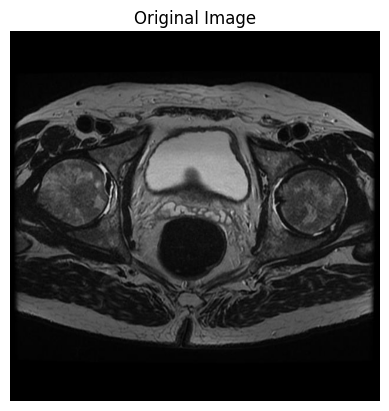

Génération 1 - Meilleur score : 5748.198564724492


Génération 2 - Meilleur score : 9550.039531236125


Génération 3 - Meilleur score : 20205.11879667902


Génération 4 - Meilleur score : 20205.11879667902


Génération 5 - Meilleur score : 20205.11879667902


Génération 6 - Meilleur score : 26585.470927121012


Génération 7 - Meilleur score : 26585.470927121012


Génération 8 - Meilleur score : 26585.470927121012


Génération 9 - Meilleur score : 26585.470927121012


Génération 10 - Meilleur score : 26585.470927121012
Noyau généré :
 [[ -4.9044585   -5.5414014    5.414013     0.7006369   -4.4585986
   -1.8471338    0.31847134]
 [ -4.3949046    4.076433    -6.496815     2.611465    -1.4012738
    6.433121     0.7643312 ]
 [ -3.566879    -0.5732484   -4.076433     2.611465    -2.1019108
    5.9872613    0.5732484 ]
 [  1.2738854    2.4840765    6.751592     0.1910828   -2.3566878
   -1.5923567    7.0700636 ]
 [ -4.3949046   -0.25477707   1.0828025    1.4649682    4.9044585
   -0.31847134   5.6050954 ]
 [  1.4012738   -1.2738854   -3.7579618    0.06369427   0.12738854
    2.611465    -1.7834395 ]
 [ -1.7834395  -10.          -1.2738854    4.968153     1.0191083
   -3.566879     1.2738854 ]]
Image enregistrée : best_generation_10.png


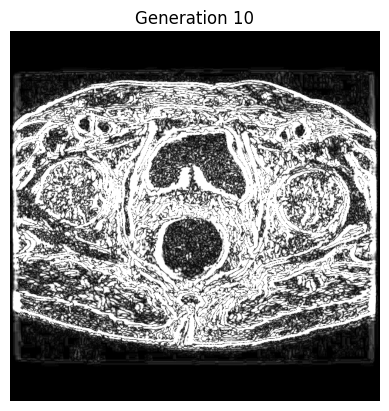

Génération 11 - Meilleur score : 26585.470927121012


Génération 12 - Meilleur score : 26585.470927121012


Génération 13 - Meilleur score : 26585.470927121012


Génération 14 - Meilleur score : 28505.05989703301


Génération 15 - Meilleur score : 28900.9033424015


Génération 16 - Meilleur score : 28900.9033424015


Génération 17 - Meilleur score : 28900.9033424015


Génération 18 - Meilleur score : 28900.9033424015


Génération 19 - Meilleur score : 28900.9033424015


Génération 20 - Meilleur score : 28900.9033424015
Noyau généré :
 [[ -2.9761906   -4.464286     3.5119047    1.3095238   -5.952381
   -1.0714285    1.5476191 ]
 [ -3.3333333    3.8095238   -4.702381     0.5952381   -1.3095238
    5.4761906    2.0238094 ]
 [ -5.714286    -1.0119047   -4.5238094    1.4880953   -1.9642857
    7.9761906   -0.17857143]
 [  0.35714287   1.4285715    4.702381     1.0119047   -3.9285715
   -0.77380955   3.9285715 ]
 [ -5.178571     1.3690476   -0.53571427   2.4404762    5.595238
    2.3214285    1.6666666 ]
 [  0.47619048   0.29761904  -2.6190476    3.1547618   -1.3690476
    4.404762    -4.047619  ]
 [  1.6666666  -10.          -0.77380955   2.9166667   -1.4880953
    1.7261904    0.6547619 ]]
Image enregistrée : best_generation_20.png


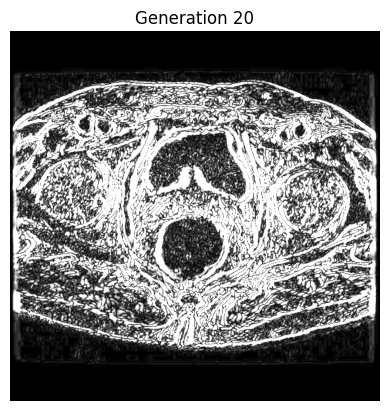

Génération 21 - Meilleur score : 28900.9033424015


Génération 22 - Meilleur score : 28900.9033424015


Génération 23 - Meilleur score : 28900.9033424015


Génération 24 - Meilleur score : 28900.9033424015


Génération 25 - Meilleur score : 28900.9033424015


Génération 26 - Meilleur score : 28900.9033424015


Génération 27 - Meilleur score : 28988.290101796258


Génération 28 - Meilleur score : 29366.26711826


Génération 29 - Meilleur score : 29366.26711826


Génération 30 - Meilleur score : 29828.566132778924
Noyau généré :
 [[ -3.0635839   -4.5086703    3.4104047    1.0982659   -5.8381505
   -0.867052     1.2716763 ]
 [ -3.0057805    3.8728323   -4.7398844    0.46242774  -1.1560694
    5.8381505    1.734104  ]
 [ -5.549133    -1.0982659   -4.33526      0.          -3.2947977
    8.092485    -0.11560693]
 [  0.11560693   1.5606936    4.450867     0.982659    -3.7572255
   -0.7514451    3.815029  ]
 [ -4.855491     1.3294798   -0.3468208    2.4855492    5.4913297
    3.8728323    1.7919075 ]
 [  0.46242774   0.5202312   -2.601156     3.2369943    0.28901735
    3.9884393   -3.9884393 ]
 [  1.734104   -10.          -0.7514451    2.3121388   -1.6184971
    1.6763005    0.40462428]]
Image enregistrée : best_generation_30.png


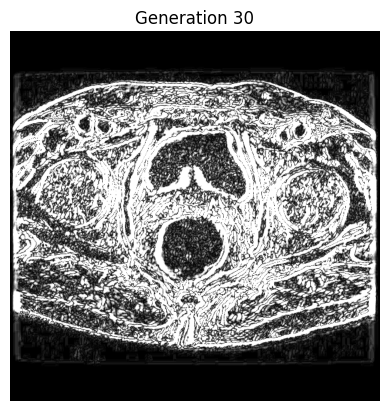

Génération 31 - Meilleur score : 29834.70497555526


Génération 32 - Meilleur score : 30299.15450601381


Génération 33 - Meilleur score : 30299.15450601381


Génération 34 - Meilleur score : 30299.15450601381


Génération 35 - Meilleur score : 30299.15450601381


Génération 36 - Meilleur score : 30375.464221108912


Génération 37 - Meilleur score : 30375.464221108912


Génération 38 - Meilleur score : 30879.950377641366


Génération 39 - Meilleur score : 30879.950377641366


Génération 40 - Meilleur score : 30879.950377641366
Noyau généré :
 [[ -2.73743     -4.1899443    3.4078212    0.9497207   -5.586592
   -1.0614525    1.396648  ]
 [ -3.1843576    3.7988827   -4.8603354    0.44692737  -1.5642458
    5.642458     1.6201117 ]
 [ -5.642458    -0.7821229   -4.0223465    0.          -2.9050279
    8.1564245    0.22346368]
 [  0.11173184   1.5083799    4.4692736    0.9497207   -3.631285
   -0.72625697   3.631285  ]
 [ -4.5810056    1.396648    -0.33519554   2.4581006    5.1396646
    2.3463688    1.6201117 ]
 [  0.2793296    0.44692737  -2.4581006    3.0167599    0.11173184
    3.9664805   -3.7988827 ]
 [  1.8994414  -10.          -0.5586592    2.9608939   -1.3407822
    1.7318436    0.33519554]]
Image enregistrée : best_generation_40.png


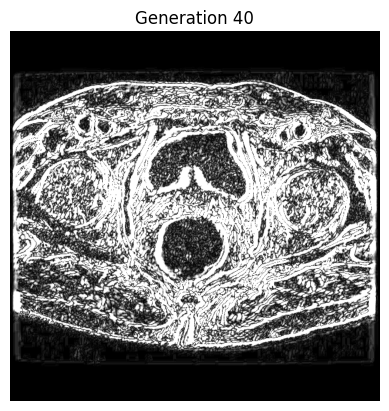

Génération 41 - Meilleur score : 30879.950377641366


Génération 42 - Meilleur score : 30879.950377641366


Génération 43 - Meilleur score : 31429.410962000693


Génération 44 - Meilleur score : 31616.489330629407


Génération 45 - Meilleur score : 31944.432976547254


Génération 46 - Meilleur score : 31944.432976547254


Génération 47 - Meilleur score : 32150.44300181804


Génération 48 - Meilleur score : 32150.44300181804


Génération 49 - Meilleur score : 32254.89720370431


Génération 50 - Meilleur score : 32310.60128231083
Noyau généré :
 [[ -2.673797    -4.0641713    3.6363637    0.96256685  -5.2406416
   -0.7486631    1.4438503 ]
 [ -3.1550803    3.7433155   -4.652406     0.48128343  -1.5508021
    5.4010696    1.7112299 ]
 [ -5.1871657   -0.85561496  -3.9037433   -0.53475934  -2.9946525
    7.8609624   -0.05347594]
 [  0.10695187   1.3368984    3.9037433    1.0160428   -3.262032
   -0.69518715   3.5294118 ]
 [ -4.4919786    1.4973263   -0.26737967   2.3529413    4.7593584
    2.513369     1.6042781 ]
 [  0.53475934   0.48128343  -2.2994652    2.459893     0.
    3.6363637   -3.5294118 ]
 [  1.7112299  -10.          -0.53475934   2.7272727   -1.0695187
    1.6042781    0.69518715]]
Image enregistrée : best_generation_50.png


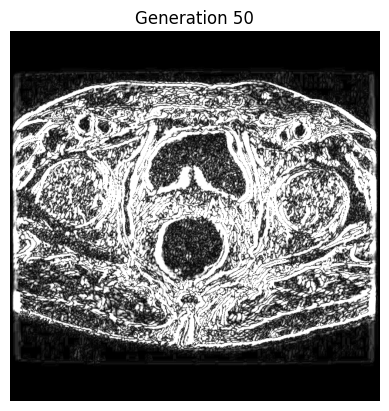

Génération 51 - Meilleur score : 32327.858812047303


Génération 52 - Meilleur score : 32327.858812047303


Génération 53 - Meilleur score : 32327.858812047303


Génération 54 - Meilleur score : 32327.858812047303


Génération 55 - Meilleur score : 32656.04536388852


Génération 56 - Meilleur score : 32833.30735139111


Génération 57 - Meilleur score : 32833.30735139111


Génération 58 - Meilleur score : 32910.812187742704


Génération 59 - Meilleur score : 32910.812187742704


Génération 60 - Meilleur score : 32910.812187742704
Noyau généré :
 [[ -2.2631578   -4.2105265    3.4210527    1.1578947   -5.4736843
   -1.2105263    1.2631578 ]
 [ -2.7894738    3.368421    -4.368421     0.36842105  -1.6315789
    5.4210525    1.6315789 ]
 [ -4.7894735   -0.47368422  -3.9473684   -0.42105263  -2.7894738
    7.5789475    0.        ]
 [ -0.05263158   1.2105263    4.2105265    0.7894737   -3.5263157
   -0.84210527   3.4736843 ]
 [ -4.4210525    1.4736842   -0.31578946   2.2105262    4.6842103
    2.1052632    1.6315789 ]
 [  0.6315789    0.2631579   -2.1578948    2.8421052    0.21052632
    3.7368422   -3.2631578 ]
 [  1.8421053  -10.          -0.36842105   2.631579    -0.94736844
    1.6315789    0.42105263]]
Image enregistrée : best_generation_60.png


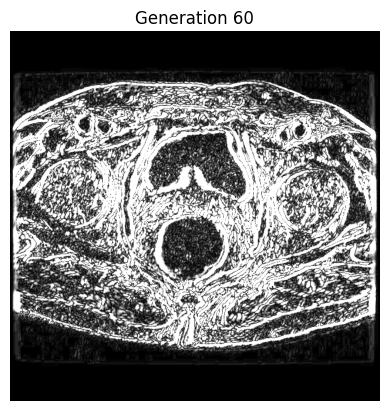

Génération 61 - Meilleur score : 33202.31616813463


Génération 62 - Meilleur score : 33229.93652121682


Génération 63 - Meilleur score : 33560.9602530859


Génération 64 - Meilleur score : 33775.227881039464


Génération 65 - Meilleur score : 33775.227881039464


Génération 66 - Meilleur score : 33781.60050276629


Génération 67 - Meilleur score : 34157.682236566674


Génération 68 - Meilleur score : 34712.05169520716


Génération 69 - Meilleur score : 34712.05169520716


Génération 70 - Meilleur score : 34805.174575643076
Noyau généré :
 [[ -2.2885573   -3.9800994    3.233831     1.1940298   -5.124378
   -1.2437811    1.3432835 ]
 [ -2.7363183    3.1343284   -4.278607     0.3482587   -1.4427861
    5.0248756    1.5920398 ]
 [ -4.5771146   -0.4477612   -3.6318407   -0.24875621  -2.437811
    7.064677    -0.04975124]
 [ -0.14925373   1.3432835    3.880597     1.0945274   -3.3333333
   -0.84577113   3.1840796 ]
 [ -4.079602     1.1940298   -0.29850745   1.9900497    4.2288556
    2.039801     1.641791  ]
 [  0.7960199   -0.04975124  -2.238806     2.686567     0.39800996
    3.5323384   -2.835821  ]
 [  1.840796   -10.          -0.04975124   2.5373135   -0.99502486
    1.4925373    0.5970149 ]]
Image enregistrée : best_generation_70.png


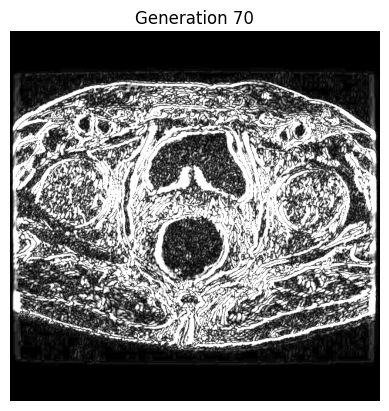

Génération 71 - Meilleur score : 35344.73357143118


Génération 72 - Meilleur score : 35344.73357143118


Génération 73 - Meilleur score : 35479.005384334705


Génération 74 - Meilleur score : 35716.17154713069


Génération 75 - Meilleur score : 35829.9280954216


Génération 76 - Meilleur score : 35947.38719949482


Génération 77 - Meilleur score : 35947.38719949482


Génération 78 - Meilleur score : 35947.38719949482


Génération 79 - Meilleur score : 36554.341575764585


Génération 80 - Meilleur score : 36554.341575764585
Noyau généré :
 [[ -2.3696682   -3.6966825    2.985782     0.8530806   -4.92891
   -1.1374408    1.1848341 ]
 [ -2.1327014    3.1753554   -4.123223     0.2843602   -1.3270142
    4.7393365    1.5165877 ]
 [ -4.3601894   -0.4265403   -3.6018958   -0.33175355  -2.3696682
    6.872038     0.09478673]
 [ -0.1421801    1.2322274    3.8388627    0.90047395  -3.127962
   -0.8530806    2.8909953 ]
 [ -3.8388627    1.3744075   -0.23696682   1.943128     3.886256
    1.7535545    1.4691943 ]
 [  0.47393364   0.2843602   -1.7061611    2.7014217    0.1421801
    3.4123223   -2.7014217 ]
 [  1.8483412  -10.           0.           2.322275    -0.7109005
    1.3270142    0.6635071 ]]
Image enregistrée : best_generation_80.png


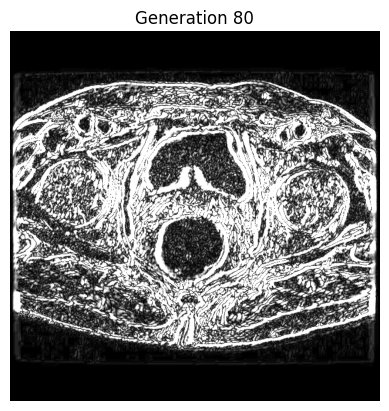

Génération 81 - Meilleur score : 36554.341575764585


Génération 82 - Meilleur score : 36633.04026357829


Génération 83 - Meilleur score : 36796.6155671655


Génération 84 - Meilleur score : 37251.932501410316


Génération 85 - Meilleur score : 37251.932501410316


Génération 86 - Meilleur score : 37499.00014336149


Génération 87 - Meilleur score : 37612.90179966653


Génération 88 - Meilleur score : 37658.14102108192


Génération 89 - Meilleur score : 37966.86769118763


Génération 90 - Meilleur score : 38117.48560834211
Noyau généré :
 [[ -2.4545455   -3.6818182    2.7727273    0.8181818   -4.5454545
   -0.90909094   1.0909091 ]
 [ -2.4545455    3.1363637   -3.7727273    0.18181819  -1.1818181
    4.5454545    1.3636364 ]
 [ -4.181818    -0.6818182   -3.5         -0.18181819  -2.409091
    6.7727275    0.09090909]
 [ -0.09090909   1.2727273    3.7272727    0.6818182   -3.
   -0.59090906   2.7727273 ]
 [ -3.6363637    1.4090909   -0.22727273   1.9090909    3.7727273
    1.6363636    1.2727273 ]
 [  0.72727275   0.22727273  -1.4545455    2.590909     0.22727273
    3.3181818   -2.6363637 ]
 [  1.8636364  -10.           0.           2.2272727   -0.8636364
    1.2272727    0.8636364 ]]
Image enregistrée : best_generation_90.png


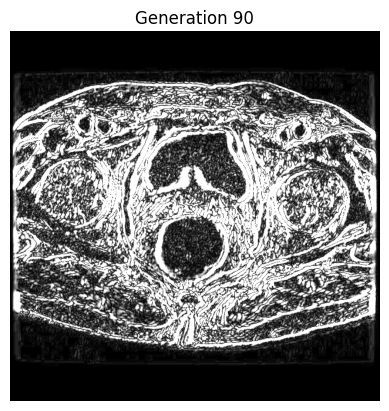

Génération 91 - Meilleur score : 38634.68483504459


Génération 92 - Meilleur score : 38634.68483504459


Génération 93 - Meilleur score : 38634.68483504459


Génération 94 - Meilleur score : 38634.68483504459


Génération 95 - Meilleur score : 38709.2272046918


Génération 96 - Meilleur score : 38837.33965298055


Génération 97 - Meilleur score : 39022.96892272554


Génération 98 - Meilleur score : 39022.96892272554


Génération 99 - Meilleur score : 39022.96892272554


Génération 100 - Meilleur score : 39057.3213144341
Noyau généré :
 [[ -2.4         -3.4666667    2.8          0.84444445  -4.3555555
   -0.8          0.8888889 ]
 [ -2.1777778    3.0666666   -3.3777778    0.26666668  -1.0666667
    4.0444446    1.2888889 ]
 [ -3.9555554   -0.8         -3.511111    -0.31111112  -2.5777779
    6.266667     0.22222222]
 [ -0.17777778   1.0222223    3.6444445    0.8888889   -3.1111112
   -0.62222224   2.8444445 ]
 [ -3.6444445    1.4222223   -0.22222222   2.088889     3.5555556
    1.7777778    1.2888889 ]
 [  0.7111111    0.26666668  -1.5111111    2.5333333    0.44444445
    3.2444444   -2.5777779 ]
 [  1.7333333  -10.          -0.17777778   2.1777778   -0.7111111
    1.2444445    1.0222223 ]]
Image enregistrée : best_generation_100.png


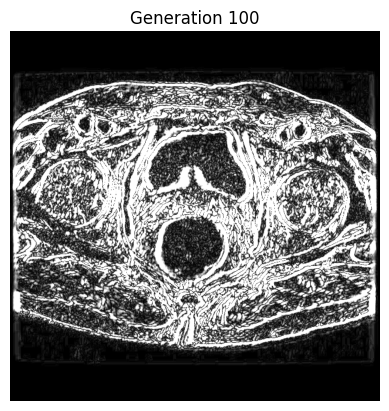

Noyau généré :
 [[ -2.4         -3.4666667    2.8          0.84444445  -4.3555555
   -0.8          0.8888889 ]
 [ -2.1777778    3.0666666   -3.3777778    0.26666668  -1.0666667
    4.0444446    1.2888889 ]
 [ -3.9555554   -0.8         -3.511111    -0.31111112  -2.5777779
    6.266667     0.22222222]
 [ -0.17777778   1.0222223    3.6444445    0.8888889   -3.1111112
   -0.62222224   2.8444445 ]
 [ -3.6444445    1.4222223   -0.22222222   2.088889     3.5555556
    1.7777778    1.2888889 ]
 [  0.7111111    0.26666668  -1.5111111    2.5333333    0.44444445
    3.2444444   -2.5777779 ]
 [  1.7333333  -10.          -0.17777778   2.1777778   -0.7111111
    1.2444445    1.0222223 ]]
Image enregistrée : best_generation_100.png


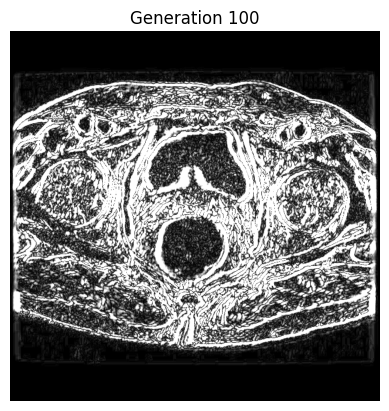

Meilleure solution trouvée avec un score de 39057.3213144341.


In [8]:
# Initialiser le placeholder avec l'image originale
display_image(bitmap_to_mat(original_image), "Original Image")

ga_instance.run()

best_solution, best_solution_fitness, best_match_idx = ga_instance.best_solution()
best_chromosome = EdgeChromosome(20)
best_chromosome.genes = [np.array(best_solution[i:i+49]).reshape(7, 7).astype(np.int64) for i in range(0, len(best_solution), 49)]
fitness.display_chromosome_result(best_chromosome, "best", ga_instance.generations_completed)
print(f"Meilleure solution trouvée avec un score de {best_solution_fitness}.")

## Conclusion et Perspectives

Dans ce TP, nous avons montre comment les algorithmes genetiques peuvent automatiser l'optimisation de filtres convolutifs pour la detection de bords. Cette approche permet une optimisation efficace de problemes complexes en traitement d'image, en tirant parti de l'evolution naturelle pour explorer l'espace des solutions.

### Ameliorations et perspectives possibles :

- Experimenter avec differentes configurations des operateurs genetiques (selection, croisement, mutation) pour ameliorer encore les resultats.
- Appliquer cette methode a d'autres types de filtres ou a des images issues de differents contextes (medicales, satellites, etc.).
- Comparer les performances obtenues avec PyGAD en Python a celles obtenues avec GeneticSharp en C# pour evaluer les avantages de chaque technologie.

Cette methode pedagogique met en evidence le potentiel et la flexibilite des algorithmes evolutionnaires en intelligence artificielle appliquee.

**Retour au sommaire** : [Index](../../README.md)

## Resume des apprentissages

Ce TP a illustre comment les **algorithmes genetiques** peuvent optimiser automatiquement un filtre convolutif de detection de bords, en utilisant la bibliotheque PyGAD.

### Concepts cles abordes

| Concept | Mise en oeuvre dans le TP |
|---------|--------------------------|
| **Chromosome** | Ensemble de 20 genes (matrices 7x7) dont la somme forme le filtre convolutif |
| **Fonction de fitness** | Correlation normalisee avec le filtre Sobel de reference, penalisee par la somme des coefficients |
| **Selection steady-state** | Les meilleurs individus sont conserves d'une generation a l'autre |
| **Croisement uniforme** | Chaque gene est echange independamment entre les deux parents |
| **Mutation aleatoire** | 10% des genes sont modifies aleatoirement pour maintenir la diversite |
| **Convergence progressive** | L'evolution ameliore iterativement le filtre sur 100 generations |

### Points essentiels a retenir

1. **La representation du probleme est cruciale** : decomposer le filtre en sous-matrices (genes) permet une evolution progressive et une exploration plus efficace de l'espace des solutions.
2. **La fonction de fitness guide l'evolution** : la combinaison de correlation et de penalisation evite les solutions triviales (filtre uniforme) tout en ciblant le resultat souhaite.
3. **Les operateurs genetiques sont configurables** : le choix de la selection, du croisement et de la mutation influence directement la qualite et la vitesse de convergence.

## Exercices

Les exercices suivants vous permettront d'approfondir votre compréhension des algorithmes génétiques appliqués à la détection de bords.

### Exercice 1 : Fonction de fitness avec préservation des bords

La fonction de fitness actuelle utilise uniquement la corrélation avec le filtre Sobel comme référence. Une amélioration possible est d'ajouter un terme qui pénalise la perte de bords importants.

**Objectif** : Modifiez la méthode `evaluate` de la classe `EdgeFitness` pour inclure un terme de préservation des bords basé sur le gradient de l'image filtrée.

**Indices** :
- Calculez le gradient moyen de l'image filtrée (plus le gradient est élevé, plus les bords sont préservés)
- Ajoutez ce terme au score avec un poids `edge_weight` (essayez 0.1 comme valeur initiale)
- Le score final pourrait être : `score = (correlation_score + edge_weight * mean_gradient) / filter_penalty`

In [9]:
def evaluate_with_edge_preservation(self, solution, solution_idx, edge_weight=0.1):
    """
    Fonction de fitness améliorée incluant un terme de préservation des bords.
    
    Parameters:
    -----------
    solution : array
        Vecteur solution du GA
    solution_idx : int
        Index de la solution
    edge_weight : float
        Poids du terme de préservation des bords
    
    Returns:
    --------
    float : Score de fitness
    """
    # TODO: Reconstruire le chromosome depuis la solution
    # (utiliser la même logique que dans evaluate)
    pass
    
    # TODO: Appliquer le filtre à l'image
    pass
    
    # TODO: Calculer la corrélation avec l'image de référence
    pass
    
    # TODO: Calculer le gradient moyen de l'image filtrée
    # Indice: utilisez cv2.Sobel pour calculer le gradient
    pass
    
    # TODO: Calculer la pénalité du filtre
    pass
    
    # TODO: Retourner le score combiné
    pass

# Ajouter la méthode à la classe EdgeFitness
EdgeFitness.evaluate_with_edge_preservation = evaluate_with_edge_preservation

print("Exercice a completer : fitness avec preservation des bords")

Exercice a completer : fitness avec preservation des bords


### Exercice 2 : Sélection par tournoi

PyGAD propose plusieurs stratégies de sélection ("sss" pour steady-state, "rws" pour roulette wheel, "sus" pour stochastic universal sampling, "rank" pour sélection par rang, "random" pour sélection aléatoire). Une stratégie populaire non incluse est la **sélection par tournoi**.

**Objectif** : Implémentez une fonction de sélection par tournoi personnalisée.

**Principe** : 
1. Sélectionnez `k` individus aléatoirement
2. Le meilleur parmi ces `k` est sélectionné comme parent
3. Répétez pour obtenir le nombre de parents souhaité

**Indices** :
- Utilisez `ga_instance.population` pour accéder à la population
- Utilisez `ga_instance.last_generation_fitness` pour les scores de fitness
- La fonction doit retourner les indices des parents sélectionnés

In [10]:
import numpy as np

def tournament_selection(ga_instance, num_parents):
    """
    Sélection par tournoi pour l'algorithme génétique.
    
    Parameters:
    -----------
    ga_instance : pygad.GA
        Instance de l'algorithme génétique
    num_parents : int
        Nombre de parents à sélectionner
    
    Returns:
    --------
    array : Indices des parents sélectionnés (shape: num_parents,)
    """
    population_size = ga_instance.population.shape[0]
    fitness = ga_instance.last_generation_fitness
    tournament_size = 3  # Nombre de participants par tournoi
    
    # TODO: Initialiser le tableau des indices de parents
    pass
    
    # TODO: Pour chaque parent à sélectionner
    #   - Choisir tournament_size individus aléatoirement
    #   - Trouver l'indice de celui avec la meilleure fitness
    #   - L'ajouter aux parents sélectionnés
    pass
    
    pass
    
    return parent_indices

# Pour utiliser cette sélection avec PyGAD, il faut définir parent_selection_type="tournament"
# et fournir la fonction via le paramètre parent_selection_type (fonction personnalisée)

print("Exercice a completer : selection par tournoi")

Exercice a completer : selection par tournoi


### Exercice 3 : Comparaison de stratégies de mutation

Le taux de mutation influence directement l'exploration de l'espace de solutions. Un taux trop faible peut mener à une convergence prématurée, tandis qu'un taux trop élevé peut empêcher la convergence.

**Objectif** : Implémentez une fonction qui compare l'impact de différents taux de mutation sur la convergence de l'algorithme.

**Indices** :
- Testez au moins 3 valeurs différentes : 5%, 10% (défaut), et 20%
- Pour chaque taux, enregistrez le meilleur score à chaque génération
- Affichez les courbes de convergence sur un même graphique
- Analysez les résultats : quel taux donne la meilleure convergence ?

In [11]:
def compare_mutation_rates(mutation_rates, num_generations=50, num_runs=3):
    """
    Compare l'impact de differents taux de mutation sur la convergence.
    
    Parameters:
    -----------
    mutation_rates : list
        Liste des taux de mutation a tester (ex: [5, 10, 20])
    num_generations : int
        Nombre de generations par execution
    num_runs : int
        Nombre d'executions pour chaque taux (pour moyennage)
    
    Returns:
    --------
    dict : Dictionnaire avec les historiques de fitness pour chaque taux
    """
    results = {rate: [] for rate in mutation_rates}
    
    # TODO: Pour chaque taux de mutation
    #       - Pour chaque execution
    #           - Configurer le GA avec ce taux de mutation (utilisez on_generation pour collecter les scores)
    #           - Executer le GA et stocker l'historique
    # TODO: Creer un graphique comparant les courbes de convergence
    #       (moyenne des executions pour chaque taux)
    
    pass  # TODO etudiant : implementez la comparaison de taux de mutation
    
    return results

# Appel de la fonction (decommentez apres implementation)
# compare_mutation_rates([5, 10, 20], num_generations=50, num_runs=3)

print("Exercice a completer : comparaison de taux de mutation")

Exercice a completer : comparaison de taux de mutation
